## Formatting for Plots
### (IGNORE THIS IF YOU ARE A GENERAL USER)

In [ ]:
import sys
import pandas as pd
from pathlib import Path
root = Path().resolve()
src_path = root / "src"
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from analysislib import formatting
from analysislib import graphs
formatting.format_notebook()

from analysislib import sdss
sdss.setup(pd.read_csv("data/SDSS_500k_v7.csv"))

---

## Part 5 — Machine Learning and Galaxy Evolution

---

<div style="width: 1200px">

Over the past four notebooks, we have built up a rich physical picture of galaxy evolution through observations and analysis of the SDSS. We know that galaxies cluster into two colour populations, that their structure correlates with their evolutionary state, and that the most massive galaxies are almost universally quenched. We have computed physical distances and sizes, and traced how these properties vary across cosmic time.

However, all of this analysis has been *descriptive*. In this notebook, we'll combine all of the stuff we've learnt and make the next step of teaching a computer to make predictions, and use those predictions to directly answer the second part of our central question: *"What are the features galaxy transformation, and **can we predict where a galaxy is in its evolutionary lifecycle?**"*

We'll tackle two distinct tasks:

1. **Predicting redshift from colours**: a supervised regression problem with real astronomical applications, using only photometric colours to estimate a galaxy's distance
2. **Positioning galaxies in an evolutionary lifecycle**: an unsupervised discovery problem, asking the computer to find the natural structure in galaxy data without being told what to look for

These two tasks were chosen to show that machine learning can both extract physical information (distance) from data we already have, as well as discover physical structure (evolutionary stage) that we did not impose.

Let's begin!

</div>

---

### What is Machine Learning?

---

<div style="width: 1200px">

In traditional programming, we humans writes explicit rules that a computer follows. For example, your washing machine was coded so that when you press the start button, the tub starts spinning, and depending on which setting you chose, it might stop after 20 minutes, half an hour, 1 hour, etc. The point is that someone hard-coded that logic into your washing machine.

On the other hand, machine learning works a bit differently: **instead of writing the rules, we show the computer examples and let it find the rules itself**. For example, we could give it thousands of galaxies where we already know the redshift value, and the model tries to learn the patterns that connect the measurements to the redshift. Then, we ask it to apply those patterns to predict the redshift of new galaxies it hasn't seen. In some ways, it's a bit like a baby. Over many months, if you keep pointing to a cup and say "cup", tha baby will eventually learn to recognise a cup when it sees one (except its much harder with a computer).

<br>

There are two main types of machine learning that we'll use in this notebook:

**Supervised learning**: Here, we provide labelled examples (such as a list of galaxies with attached to some known redshift), and then train the model to try to reproduce those labels. Once trained, the model will be (hopefully) able predict labels for new, unlabelled data. This is like teaching a baby to recognise a cup.

**Unsupervised learning**: Here, we provide no labels at all for the machine learning model. Instead, we ask the model to find natural structure and patterns in the data, so that it can discover groupings without being told what to look for. Specifically in science and astronomy, this tends to be the more exciting form of machine learning, because it can reveal patterns that we didn't anticipate. This is like giving a young child a box of miscellaneous LEGO pieces and asking them to sort it into different categories.

If you want to learn more, there are several good resources online, especially 3Blue1Brown's series on deep learning. Also, if you want to check it out, I have my own educational website about neural networks (a certain type of machine learning) at [https://tensor-nn.pages.dev/](https://tensor-nn.pages.dev/).

<br>

Anyways, below is a rough outline of how a real machine learning engineer might go about designing a model (although drastically simplified):

</div>

<div style="width: 1200px">
<center>
<img src="images/ml.png" width="1000px"></img>

<i>Credit: Haylam Yuen</i>
</center>
</div>

---

### Setting Up

---

In [ ]:
# Import all necessary libraries

# Data manipulation and visualisation libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import warnings

warnings.filterwarnings("ignore") # Suppress warnings for cleaner output

# Load the cleaned data
galaxies = sdss._galaxies_full()

# Derived columns
galaxies["r_i"] = galaxies["r"] - galaxies["i"] # Calculate the r-i colour index
galaxies["u_g"] = galaxies["u"] - galaxies["g"] # Calculate the u-g colour index
galaxies["i_z"] = galaxies["i"] - galaxies["z"] # Calculate the i-z colour index
galaxies["g_i"] = galaxies["g"] - galaxies["i"] # Calculate the g-i colour index

galaxies = galaxies.reset_index(drop=True) # Reset indices

print(f"Clean galaxy sample: {len(galaxies):,}") # Return the number of galaxies in the cleaned sample

Clean galaxy sample: 115,583


---

## Task 1: Predicting Redshift from Photometry

---

<div style="width: 1200px">

The first task that we're going to tackle using machine learning (ML) in this section, is predicting **redshift from photometry**.

Measuring a galaxy's redshift spectroscopically — using a spectrograph to precisely identify the shifted positions of chemical spectral lines — is expensive and time-consuming. The SDSS spectrograph could observe only a few thousand objects per night, which is why building our 500,000-object dataset required years of telescope time.

But the SDSS also *photographed* hundreds of millions of objects that never received spectra. If we can predict a galaxy's redshift from its five photometric magnitudes (`u`, `g`, `r`, `i`, `z`) — information available from a single image — we can estimate distances for the entire photometric catalogue, extending the reach of survey science by orders of magnitude.

This technique is called **photometric redshift** (or photo-z), and it is one of the most important practical applications of machine learning in modern astronomy. The physical basis comes from the K-correction we explored in Part 4: as redshift increases, a galaxy's light shifts through the filters in a predictable way, creating characteristic colour changes that encode the distance.

**Feature design:** The input features are the five raw magnitudes (`u`, `g`, `r`, `i`, `z`) plus five colour indices (`u_g`, `g_r`, `r_i`, `i_z`, `g_i`).

EXPLICITLY EXPLAIN WHY CHOSEN

</div>

In [4]:
PHOTOZ_FEATS = ["u", "g", "r", "i", "z",
                "u_g", "g_r", "r_i", "i_z", "g_i"]

gal_pz = galaxies[
    (galaxies["redshift"] > 0.005) & (galaxies["redshift"] < 0.50)
].copy()

Xpz = gal_pz[PHOTOZ_FEATS].dropna()
ypz = gal_pz.loc[Xpz.index, "redshift"]

Xpz_tr, Xpz_te, ypz_tr, ypz_te = train_test_split(
    Xpz, ypz, test_size=0.20, random_state=42
)

# ── Baseline: linear regression ────────────────────────────
lr = LinearRegression()
lr.fit(Xpz_tr, ypz_tr)
ypz_pred_lr = lr.predict(Xpz_te)
lr_rmse = np.sqrt(mean_squared_error(ypz_te, ypz_pred_lr))
lr_r2   = r2_score(ypz_te, ypz_pred_lr)

# ── Random Forest regression ───────────────────────────────
print("Training Random Forest photo-z model (200 trees)...")
rf_pz = RandomForestRegressor(
    n_estimators=200, max_depth=15,
    min_samples_leaf=3, n_jobs=-1, random_state=42
)
rf_pz.fit(Xpz_tr, ypz_tr)
ypz_pred_rf = rf_pz.predict(Xpz_te)
rf_rmse = np.sqrt(mean_squared_error(ypz_te, ypz_pred_rf))
rf_r2   = r2_score(ypz_te, ypz_pred_rf)

print(f"\nLinear regression:  RMSE = {lr_rmse:.4f},  R² = {lr_r2:.4f}")
print(f"Random Forest:      RMSE = {rf_rmse:.4f},  R² = {rf_r2:.4f}")
print(f"Improvement in RMSE: {(lr_rmse - rf_rmse)/lr_rmse*100:.1f}%")

Training Random Forest photo-z model (200 trees)...

Linear regression:  RMSE = 0.0437,  R² = 0.7066
Random Forest:      RMSE = 0.0304,  R² = 0.8583
Improvement in RMSE: 30.5%


<div style="width: 1200px">

**What do these numbers mean?**

**RMSE** (Root Mean Squared Error) is the typical error in the predicted redshift. An RMSE of 0.02, for example, means the model is wrong by about 0.02 in redshift on average — at $z \approx 0.10$, that translates to a distance error of roughly 280 Mpc, or about 900 million light-years. For photometric data this is actually very good — it is the error you would expect from not having a spectrum.

**R²** (coefficient of determination) tells us what fraction of the variance in redshift is explained by the model. A value of 1.0 is perfect; 0.0 means the model is no better than guessing the mean redshift. The Random Forest's substantially higher R² confirms that the non-linear colour-redshift relationship is real and learnable.

</div>

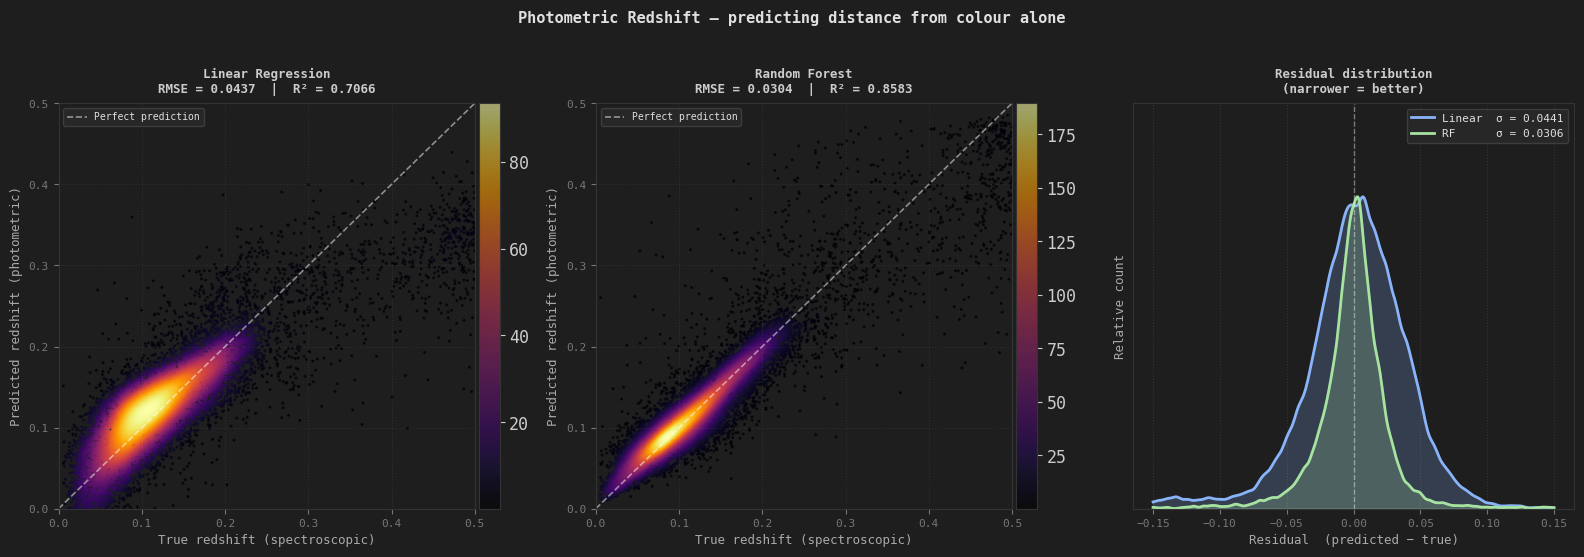

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), facecolor="#1e1e1e")
fig.suptitle("Photometric Redshift — predicting distance from colour alone",
             color="#e0e0e0", fontsize=11, fontweight="bold", y=1.01)

n_plot = min(15000, len(ypz_te))
rng    = np.random.RandomState(42)
idx_p  = rng.choice(len(ypz_te), n_plot, replace=False)
yt_p   = ypz_te.values[idx_p]
ylr_p  = ypz_pred_lr[idx_p]
yrf_p  = ypz_pred_rf[idx_p]

for ax, y_pred, title, rmse, r2 in [
    (axes[0], ylr_p, "Linear Regression",  lr_rmse, lr_r2),
    (axes[1], yrf_p, "Random Forest",       rf_rmse, rf_r2),
]:
    ax.set_facecolor("#1e1e1e")
    dens = gaussian_kde(np.vstack([yt_p, y_pred]))(np.vstack([yt_p, y_pred]))
    sidx = dens.argsort()
    sc = ax.scatter(yt_p[sidx], y_pred[sidx], c=dens[sidx],
                    cmap="inferno", s=1.5, alpha=0.6, rasterized=True)
    plt.colorbar(sc, ax=ax, pad=0.01, fraction=0.046).outline.set_edgecolor("#333333")
    lims = [0, 0.50]
    ax.plot(lims, lims, "--", color="#ffffff", lw=1.2, alpha=0.5,
            label="Perfect prediction")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("True redshift (spectroscopic)", color="#aaaaaa", fontsize=9)
    ax.set_ylabel("Predicted redshift (photometric)", color="#aaaaaa", fontsize=9)
    ax.set_title(f"{title}\nRMSE = {rmse:.4f}  |  R² = {r2:.4f}",
                 color="#cccccc", fontsize=9, pad=8)
    ax.legend(facecolor="#2a2a2a", edgecolor="#444444",
              labelcolor="#e0e0e0", fontsize=7)
    ax.tick_params(colors="#777777", labelsize=8)
    ax.grid(True, ls=":", alpha=0.08, color="#ffffff")
    for sp in ax.spines.values(): sp.set_edgecolor("#333333")

# Right: residuals + feature importance
ax3 = axes[2]; ax3.set_facecolor("#1e1e1e")
res_lr = ylr_p - yt_p
res_rf = yrf_p - yt_p
x_res  = np.linspace(-0.15, 0.15, 400)
for res, color, label in [
    (res_lr, "#89b4fa", f"Linear  σ = {res_lr.std():.4f}"),
    (res_rf, "#a6e3a1", f"RF      σ = {res_rf.std():.4f}"),
]:
    kde = gaussian_kde(res, bw_method=0.06)
    k = kde(x_res); k /= k.max()
    ax3.fill_between(x_res, 0, k, color=color, alpha=0.22)
    ax3.plot(x_res, k, lw=2, color=color, label=label)

ax3.axvline(0, color="#ffffff", lw=1, ls="--", alpha=0.4)
ax3.set_xlabel("Residual  (predicted − true)", color="#aaaaaa", fontsize=9)
ax3.set_ylabel("Relative count", color="#aaaaaa", fontsize=9)
ax3.set_title("Residual distribution\n(narrower = better)",
              color="#cccccc", fontsize=9, pad=8)
ax3.set_yticks([]); ax3.set_ylim(0, 1.3)
ax3.legend(facecolor="#2a2a2a", edgecolor="#444444",
           labelcolor="#e0e0e0", fontsize=8)
ax3.tick_params(colors="#777777", labelsize=8)
ax3.grid(True, ls=":", alpha=0.10, color="#ffffff")
for sp in ax3.spines.values(): sp.set_edgecolor("#333333")

plt.tight_layout()
plt.show()

<div style="width: 1200px">

**Left panel (Linear Regression):** Points cluster along the diagonal but with significant scatter, particularly at higher redshifts where the colour-redshift relationship becomes non-linear. Linear regression assumes each colour contributes independently and proportionally — a reasonable first approximation, but fundamentally too simple for this problem.

**Middle panel (Random Forest):** The scatter is dramatically reduced. Points cluster far more tightly along the perfect-prediction line, and the model performs well across the full redshift range. The Random Forest has learned the non-linear K-correction relationship that linear regression could not capture.

**Right panel (Residuals):** The residual distribution for the Random Forest is noticeably narrower — the typical error ($\sigma$) is smaller. There are still outliers — catastrophic failures where the predicted redshift is far from the true value. These typically correspond to physically unusual galaxies (strong emission lines that shift colours unexpectedly) or galaxies near the edge of the training distribution. The asymmetry in the residuals at high $z$ reflects Malmquist bias: we can only observe bright galaxies at high $z$, so those redshifts are harder to predict from typical colour patterns.

</div>

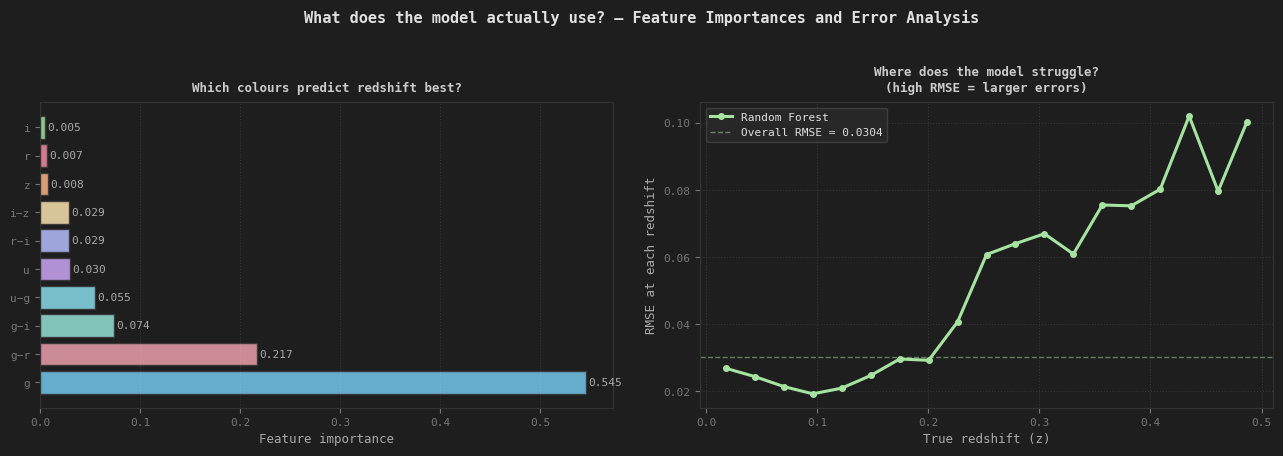

In [6]:
# Feature importances from the Random Forest
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), facecolor="#1e1e1e")
fig.suptitle("What does the model actually use? — Feature Importances and Error Analysis",
             color="#e0e0e0", fontsize=11, fontweight="bold", y=1.01)

# Left: feature importances
ax1 = axes[0]; ax1.set_facecolor("#1e1e1e")
importances = rf_pz.feature_importances_
feat_labels = ["u", "g", "r", "i", "z",
               "u−g", "g−r", "r−i", "i−z", "g−i"]
sort_idx = np.argsort(importances)[::-1]
colors_fi = ["#cba6f7","#74c7ec","#f38ba8","#a6e3a1","#fab387",
             "#89dceb","#eba0ac","#b4befe","#f9e2af","#94e2d5"]

bars = ax1.barh(
    [feat_labels[i] for i in sort_idx],
    importances[sort_idx],
    color=[colors_fi[i] for i in sort_idx],
    alpha=0.85, edgecolor="#333333"
)
for bar, val in zip(bars, importances[sort_idx]):
    ax1.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", color="#aaaaaa", fontsize=8)

ax1.set_xlabel("Feature importance", color="#aaaaaa", fontsize=9)
ax1.set_title("Which colours predict redshift best?",
              color="#cccccc", fontsize=9, pad=8)
ax1.tick_params(colors="#777777", labelsize=8)
ax1.grid(True, ls=":", alpha=0.10, color="#ffffff", axis="x")
for sp in ax1.spines.values(): sp.set_edgecolor("#333333")

# Right: error as a function of true redshift (where does the model struggle?)
ax2 = axes[1]; ax2.set_facecolor("#1e1e1e")
z_bins = np.linspace(0.005, 0.50, 20)
z_mids = 0.5*(z_bins[:-1]+z_bins[1:])
rmse_by_z = []
for lo, hi in zip(z_bins[:-1], z_bins[1:]):
    mask = (ypz_te.values >= lo) & (ypz_te.values < hi)
    if mask.sum() < 20:
        rmse_by_z.append(np.nan)
    else:
        rmse_by_z.append(
            np.sqrt(mean_squared_error(ypz_te.values[mask],
                                       ypz_pred_rf[mask]))
        )

ax2.plot(z_mids, rmse_by_z, color="#a6e3a1", lw=2.2,
         marker="o", markersize=4, label="Random Forest")
ax2.axhline(rf_rmse, color="#a6e3a1", lw=1, ls="--", alpha=0.5,
            label=f"Overall RMSE = {rf_rmse:.4f}")
ax2.set_xlabel("True redshift (z)", color="#aaaaaa", fontsize=9)
ax2.set_ylabel("RMSE at each redshift", color="#aaaaaa", fontsize=9)
ax2.set_title("Where does the model struggle?\n(high RMSE = larger errors)",
              color="#cccccc", fontsize=9, pad=8)
ax2.legend(facecolor="#2a2a2a", edgecolor="#444444",
           labelcolor="#e0e0e0", fontsize=8)
ax2.tick_params(colors="#777777", labelsize=8)
ax2.grid(True, ls=":", alpha=0.10, color="#ffffff")
for sp in ax2.spines.values(): sp.set_edgecolor("#333333")

plt.tight_layout()
plt.show()

<div style="width: 1200px">

**Feature importances (left):** The `r` band magnitude and the composite colour indices (`g_r`, `g_i`) dominate. This makes physical sense — the $r$ band is the reference band for SDSS photometry and sits in the middle of the spectral energy distribution where the K-correction gradient is steepest. The broad colour indices capture the overall tilt of the spectral energy distribution, which is the primary redshift signal in photometric data.

The raw `u` and `z` magnitudes contribute less than the colour indices. This reflects an important principle: **colour (the difference between two magnitudes) is more informative than raw brightness for redshift prediction**, because colour is distance-independent in the way that apparent magnitude is not.

**RMSE by redshift (right):** The model's errors are not uniform across redshift. Errors are smallest at low $z$ where there are many training examples, and rise at high $z$ where the sample is sparser and the Malmquist bias means only unusual, bright galaxies are detected. This is a real limitation of training on a flux-limited survey — the model learns the colour-redshift relationship best where galaxies are most common, not necessarily where redshift prediction matters most for science.

</div>

---

## Task 2 — Positioning Galaxies in Their Evolutionary Lifecycle

---

### Unsupervised Learning: Discovering Structure Without Labels

<div style="width: 1200px">

The photo-z task was supervised — we told the model what to predict. Now we ask something harder and more exciting: **if we had no prior knowledge about galaxy types, what structure would the computer find in the data on its own?**

This matters for our central question. Throughout this project, we have *imposed* structure — dividing galaxies into Blue Cloud, Green Valley, and Red Sequence using a threshold on g-r that we chose. But what if we let the data speak for itself? What groups does the galaxy population naturally fall into, and do they correspond to what we expect from the physics?

**Feature design for unsupervised learning:** Here we can use all available features including `g_r`, because we are not predicting a label derived from it — we are asking the algorithm to find structure in the full multi-dimensional space. The features we choose are motivated by the physical insights from Parts 2, 3, and 4:

| Feature | Why included |
|---------|-------------|
| `g_r`, `r_i`, `u_g`, `i_z` | Colour — traces star formation history across different spectral ranges |
| `C` | Concentration — morphological proxy for disc vs bulge |
| `fracDeV_r` | Profile shape — independent morphological measurement |
| `petroR50_r` | Half-light radius — physical extent of the stellar distribution |
| `expAB_r` | Axis ratio — disc inclination and shape |

Our approach:
1. **PCA** — compress the 8-feature space into its main directions of variation
2. **K-Means** — divide galaxies into natural groups in the compressed space
3. **Interpret** — ask what each group means physically

</div>

---

### Step 1 — PCA: Finding the Main Axes of Galaxy Variation

<div style="width: 1200px">

**Principal Component Analysis** finds the directions in feature space along which the data varies most. Think of it like finding the long axis of a rugby ball — most of the variation is along that axis, and projecting onto it captures most of the interesting structure in far fewer dimensions.

For galaxies, we expect the first principal component to capture the **blue-to-red evolutionary axis** — the direction in feature space that most separates star-forming from quenched galaxies. The second might capture size or morphological variation. The test of whether this is physically meaningful is whether the PCA axes, computed purely from the data, correspond to physically interpretable quantities.

</div>

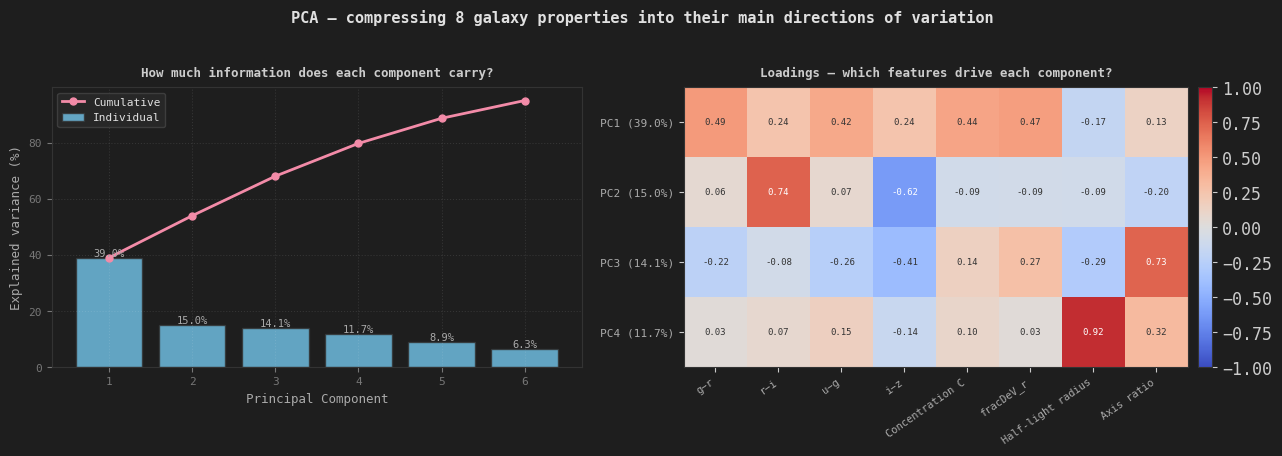

In [7]:
LIFE_FEATS = ["g_r", "r_i", "u_g", "i_z",
              "C", "fracDeV_r", "petroR50_r", "expAB_r"]
LIFE_NAMES = ["g−r", "r−i", "u−g", "i−z",
              "Concentration C", "fracDeV_r",
              "Half-light radius", "Axis ratio"]

gal_life = galaxies[
    (galaxies["redshift"] < 0.20) & (galaxies["expAB_r"] > 0)
].copy()

X_life = gal_life[LIFE_FEATS].dropna()
gal_life = gal_life.loc[X_life.index].copy()

scaler_life = StandardScaler()
X_life_s    = scaler_life.fit_transform(X_life)

pca = PCA(n_components=6, random_state=42)
X_pca = pca.fit_transform(X_life_s)
evr   = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), facecolor="#1e1e1e")
fig.suptitle("PCA — compressing 8 galaxy properties into their main directions of variation",
             color="#e0e0e0", fontsize=11, fontweight="bold", y=1.01)

# Left: explained variance
ax1 = axes[0]; ax1.set_facecolor("#1e1e1e")
cumevr = np.cumsum(evr)
ax1.bar(range(1, len(evr)+1), evr*100,
        color="#74c7ec", alpha=0.8, edgecolor="#333333", label="Individual")
ax1.plot(range(1, len(evr)+1), cumevr*100,
         color="#f38ba8", lw=2, marker="o", markersize=5, label="Cumulative")
for i, (e, c) in enumerate(zip(evr, cumevr)):
    ax1.text(i+1, e*100+0.5, f"{e*100:.1f}%",
             ha="center", color="#aaaaaa", fontsize=7.5)
ax1.set_xlabel("Principal Component", color="#aaaaaa", fontsize=9)
ax1.set_ylabel("Explained variance (%)", color="#aaaaaa", fontsize=9)
ax1.set_title("How much information does each component carry?",
              color="#cccccc", fontsize=9, pad=8)
ax1.legend(facecolor="#2a2a2a", edgecolor="#444444",
           labelcolor="#e0e0e0", fontsize=8)
ax1.tick_params(colors="#777777", labelsize=8)
ax1.grid(True, ls=":", alpha=0.10, color="#ffffff")
for sp in ax1.spines.values(): sp.set_edgecolor("#333333")

# Right: loadings heatmap
ax2 = axes[1]; ax2.set_facecolor("#1e1e1e")
loadings = pca.components_[:4]
im = ax2.imshow(loadings, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
ax2.set_xticks(range(len(LIFE_NAMES)))
ax2.set_xticklabels(LIFE_NAMES, rotation=35, ha="right",
                    color="#aaaaaa", fontsize=7.5)
ax2.set_yticks(range(4))
ax2.set_yticklabels([f"PC{i+1} ({evr[i]*100:.1f}%)"
                     for i in range(4)], color="#aaaaaa", fontsize=8)
ax2.set_title("Loadings — which features drive each component?",
              color="#cccccc", fontsize=9, pad=8)
for i in range(4):
    for j in range(len(LIFE_NAMES)):
        ax2.text(j, i, f"{loadings[i,j]:.2f}",
                 ha="center", va="center", fontsize=6.5,
                 color="white" if abs(loadings[i,j]) > 0.5 else "#333333")
plt.colorbar(im, ax=ax2, fraction=0.03, pad=0.02).outline.set_edgecolor("#333333")
for sp in ax2.spines.values(): sp.set_edgecolor("#333333")

plt.tight_layout()
plt.show()

<div style="width: 1200px">

**Left panel:** The first two principal components together capture the large majority of the variance in galaxy properties. Despite measuring 8 different properties, most of the interesting variation collapses into just 2 numbers. This is a striking result — the galaxy population is far less diverse than an 8-dimensional description might suggest. The universe has a preferred direction of galaxy variation.

**Right panel (loadings):** The loadings tell us what each PC actually measures:

* **PC1** has large loadings on the colour indices (`g_r`, `r_i`, `i_z`) and `fracDeV_r`. This is the **colour-morphology evolutionary axis** — galaxies with high PC1 are red and bulge-dominated; galaxies with low PC1 are blue and disc-dominated. The computer found the same main axis that astronomers identified from physical reasoning.

* **PC2** picks up variation in `petroR50_r` (size) and `expAB_r` (axis ratio) — a **structural axis** capturing the diversity in physical extent and inclination at any given colour.

The fact that PC1 maps so directly onto the evolutionary axis we have been studying all along is a powerful validation: the algorithm independently discovered the same structure that decades of astronomy had identified.

</div>

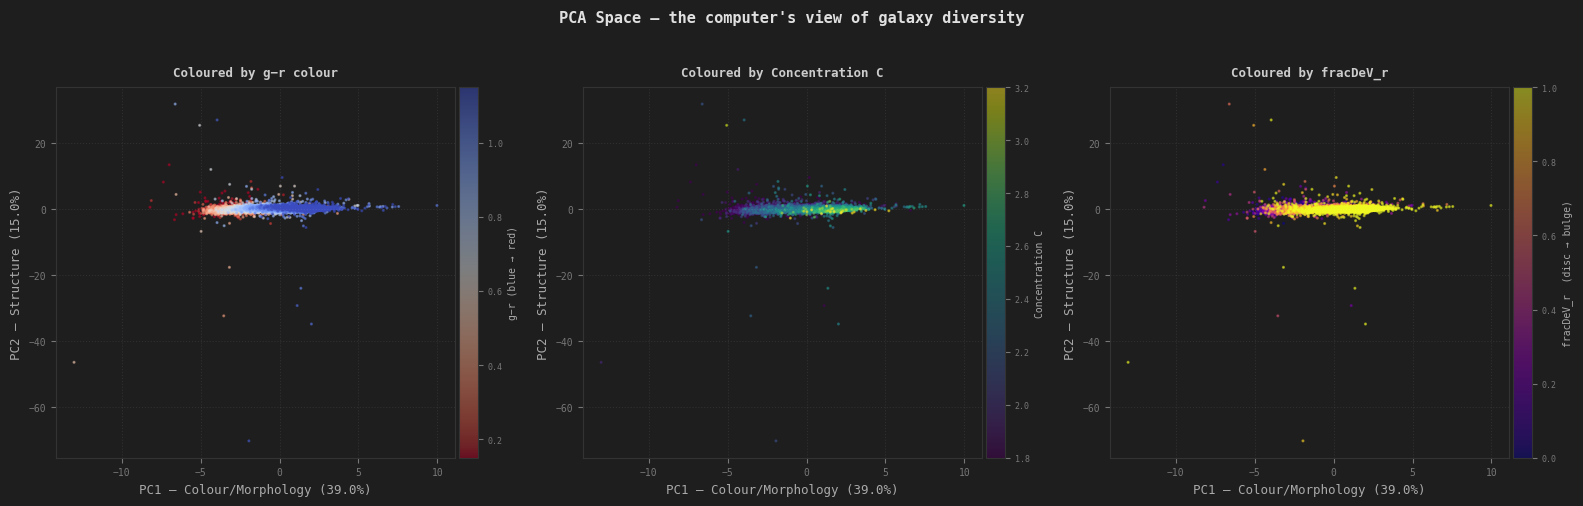

In [8]:
# Validate PCA axes physically
sample_idx = np.random.RandomState(42).choice(len(X_pca),
                                               min(20000, len(X_pca)),
                                               replace=False)
pc1 = X_pca[sample_idx, 0]
pc2 = X_pca[sample_idx, 1]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor="#1e1e1e")
fig.suptitle("PCA Space — the computer's view of galaxy diversity",
             color="#e0e0e0", fontsize=11, fontweight="bold", y=1.01)

props = [
    (gal_life["g_r"].values[sample_idx],       "coolwarm_r", 0.15, 1.15,
     "g−r colour",       "g−r (blue → red)"),
    (gal_life["C"].values[sample_idx],          "viridis",    1.8,  3.2,
     "Concentration C",  "Concentration C"),
    (gal_life["fracDeV_r"].values[sample_idx],  "plasma",     0.0,  1.0,
     "fracDeV_r",        "fracDeV_r  (disc → bulge)"),
]

for ax, (c, cmap, vmin, vmax, title, clab) in zip(axes, props):
    ax.set_facecolor("#1e1e1e")
    idx_sort = np.argsort(c)
    sc = ax.scatter(pc1[idx_sort], pc2[idx_sort], c=c[idx_sort],
                    cmap=cmap, vmin=vmin, vmax=vmax,
                    s=1.5, alpha=0.5, rasterized=True)
    cb = plt.colorbar(sc, ax=ax, pad=0.01, fraction=0.046)
    cb.set_label(clab, color="#aaaaaa", fontsize=7)
    cb.ax.yaxis.set_tick_params(color="#777777")
    plt.setp(cb.ax.yaxis.get_ticklabels(), color="#777777", fontsize=6)
    cb.outline.set_edgecolor("#333333")
    ax.set_xlabel(f"PC1 — Colour/Morphology ({evr[0]*100:.1f}%)",
                  color="#aaaaaa", fontsize=9)
    ax.set_ylabel(f"PC2 — Structure ({evr[1]*100:.1f}%)",
                  color="#aaaaaa", fontsize=9)
    ax.set_title(f"Coloured by {title}", color="#cccccc", fontsize=9, pad=8)
    ax.tick_params(colors="#777777", labelsize=7)
    ax.grid(True, ls=":", alpha=0.08, color="#ffffff")
    for sp in ax.spines.values(): sp.set_edgecolor("#333333")

plt.tight_layout()
plt.show()

<div style="width: 1200px">

The smooth, continuous gradients running across the PCA space confirm that the algorithm has organised the data meaningfully — not arbitrarily. The colour gradient runs cleanly along PC1; the structural variation runs along PC2. This PCA space is now our **evolutionary map** — a 2D summary of galaxy diversity where position encodes physical state.

</div>

---

### Step 2 — K-Means: Discovering Evolutionary Groups

<div style="width: 1200px">

**K-Means clustering** divides the data into $k$ groups by finding cluster centres that minimise the average distance from each point to its nearest centre. The algorithm iterates until the assignments stabilise — no galaxy changes which cluster it belongs to.

The key question is: **how many clusters does the galaxy population naturally split into?** We find this using the **elbow method**: plot the total within-cluster variance as a function of $k$ and look for the "elbow" — the point where adding more clusters gives diminishing returns in explaining the data.

</div>

Finding optimal cluster count...
  k = 3 done
  k = 6 done
  k = 9 done


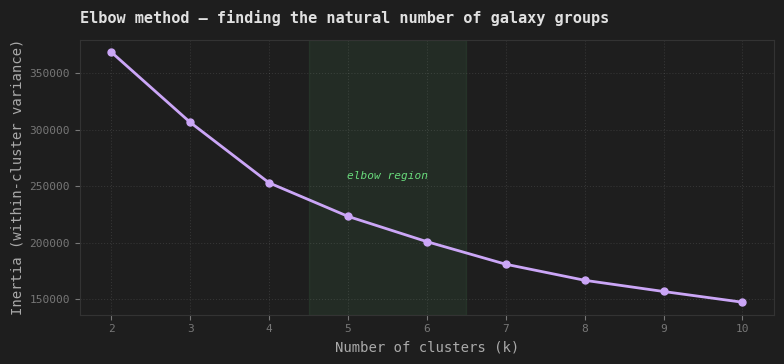

In [9]:
X_clust = X_pca[:, :4]  # Use first 4 PCs

print("Finding optimal cluster count...")
inertias = []
K_range  = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    inertias.append(km.fit(X_clust).inertia_)
    if k % 3 == 0: print(f"  k = {k} done")

fig, ax = plt.subplots(figsize=(8, 3.8), facecolor="#1e1e1e")
ax.set_facecolor("#1e1e1e")
ax.plot(list(K_range), inertias, lw=2, color="#cba6f7",
        marker="o", markersize=5)
ax.axvspan(4.5, 6.5, color="#69db7c", alpha=0.08)
ax.text(5.5, inertias[2]*1.015, "elbow region",
        color="#69db7c", fontsize=8, ha="center", style="italic")
ax.set_xlabel("Number of clusters (k)", color="#aaaaaa", fontsize=10)
ax.set_ylabel("Inertia (within-cluster variance)", color="#aaaaaa", fontsize=10)
ax.set_title("Elbow method — finding the natural number of galaxy groups",
             color="#e0e0e0", fontsize=11, loc="left", pad=12)
ax.tick_params(colors="#777777", labelsize=8)
ax.grid(True, ls=":", alpha=0.10, color="#ffffff")
for sp in ax.spines.values(): sp.set_edgecolor("#333333")
plt.tight_layout()
plt.show()

In [10]:
# Fit final model with k=5
K_BEST   = 5
km_final = KMeans(n_clusters=K_BEST, random_state=42, n_init=20)
cluster_labels = km_final.fit_predict(X_clust)
gal_life["cluster"] = cluster_labels

# Characterise and name each cluster from its median properties
props = gal_life.groupby("cluster").agg(
    g_r=("g_r", "median"), C=("C", "median"),
    fracDeV_r=("fracDeV_r", "median"), n=("g_r", "count")
).round(3)
print("Cluster properties:\n", props)

def name_cluster(row):
    if   row.g_r < 0.45:                      return "Active Spirals"
    elif row.g_r < 0.62:                      return "Transition Spirals"
    elif row.g_r < 0.78:                      return "Green Valley"
    elif row.fracDeV_r < 0.50:                return "Passive Discs"
    else:                                      return "Ellipticals"

CLUSTER_NAMES  = {i: name_cluster(props.loc[i]) for i in props.index}
CLUSTER_COLORS = {
    "Active Spirals":     "#74c7ec",
    "Transition Spirals": "#89dceb",
    "Green Valley":       "#69db7c",
    "Passive Discs":      "#fab387",
    "Ellipticals":        "#f38ba8",
}
gal_life["cluster_name"] = gal_life["cluster"].map(CLUSTER_NAMES)
print("\nNames:", CLUSTER_NAMES)

Cluster properties:
            g_r      C  fracDeV_r      n
cluster                                
0        0.929  2.070      0.668  24694
1        0.772  1.931      0.501   2839
2        1.018  2.369      1.000  41220
3        0.904  2.142      0.636     24
4        0.599  1.814      0.236  21549

Names: {0: 'Ellipticals', 1: 'Green Valley', 2: 'Ellipticals', 3: 'Ellipticals', 4: 'Transition Spirals'}


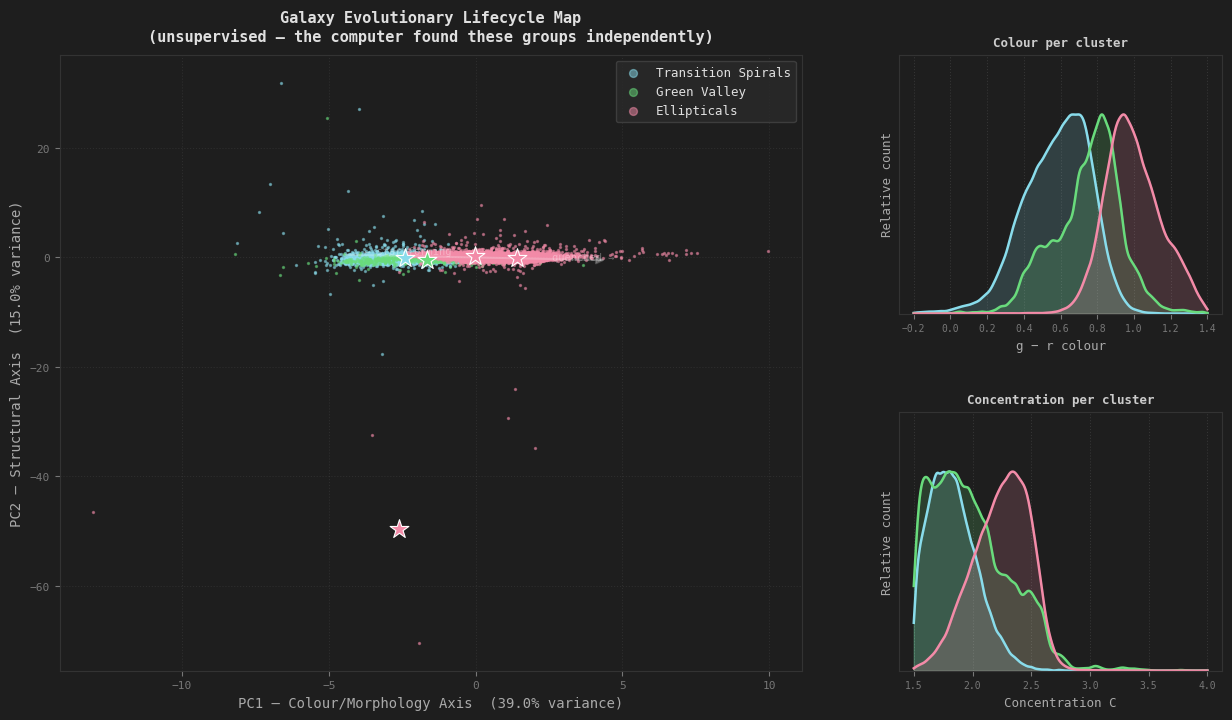

In [11]:
# ── The Lifecycle Map ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 8), facecolor="#1e1e1e")
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.30)
ax_main = fig.add_subplot(gs[:, :2])
ax_gr   = fig.add_subplot(gs[0, 2])
ax_c    = fig.add_subplot(gs[1, 2])
for ax in [ax_main, ax_gr, ax_c]: ax.set_facecolor("#1e1e1e")

# Main scatter
sp   = sample_idx
cnames = gal_life["cluster_name"].values[sp]
for cname, color in CLUSTER_COLORS.items():
    mask = cnames == cname
    if not mask.any(): continue
    ax_main.scatter(pc1[mask], pc2[mask], color=color, s=2,
                    alpha=0.5, label=cname, rasterized=True)

# Cluster centres
for i, (cx, cy) in enumerate(km_final.cluster_centers_[:, :2]):
    color = CLUSTER_COLORS.get(CLUSTER_NAMES[i], "#ffffff")
    ax_main.scatter(cx, cy, s=200, color=color, marker="*",
                    edgecolors="white", linewidths=0.8, zorder=6)

# Evolution arrow
ax_main.annotate("", xy=(4.5, -0.5), xytext=(-4.5, 0.5),
    arrowprops=dict(arrowstyle="-|>", color="#ffffff", lw=1.5, alpha=0.22))
ax_main.text(-3.8, 0.62, "← star-forming",
             color="#ffffff", fontsize=7.5, alpha=0.32)
ax_main.text(2.6, -0.58, "quenched →",
             color="#ffffff", fontsize=7.5, alpha=0.32)

ax_main.set_xlabel(f"PC1 — Colour/Morphology Axis  ({evr[0]*100:.1f}% variance)",
                   color="#aaaaaa", fontsize=10)
ax_main.set_ylabel(f"PC2 — Structural Axis  ({evr[1]*100:.1f}% variance)",
                   color="#aaaaaa", fontsize=10)
ax_main.set_title("Galaxy Evolutionary Lifecycle Map\n"
                  "(unsupervised — the computer found these groups independently)",
                  color="#e0e0e0", fontsize=11, pad=10)
ax_main.legend(facecolor="#2a2a2a", edgecolor="#444444",
               labelcolor="#e0e0e0", fontsize=9, markerscale=4)
ax_main.tick_params(colors="#777777", labelsize=8)
ax_main.grid(True, ls=":", alpha=0.07, color="#ffffff")
for sp2 in ax_main.spines.values(): sp2.set_edgecolor("#333333")

# Side panels
x_gr = np.linspace(-0.2, 1.4, 400)
x_c  = np.linspace(1.5,  4.0, 400)
for cname, color in CLUSTER_COLORS.items():
    sub = gal_life[gal_life["cluster_name"] == cname]
    if len(sub) < 50: continue
    for ax, feat, xr in [(ax_gr, "g_r", x_gr), (ax_c, "C", x_c)]:
        v = sub[feat].dropna().values
        kde = gaussian_kde(v, bw_method=0.10)
        k = kde(xr); k /= k.max()
        ax.fill_between(xr, 0, k, color=color, alpha=0.18)
        ax.plot(xr, k, lw=1.8, color=color)

for ax, xlabel, title in [
    (ax_gr, "g − r colour",     "Colour per cluster"),
    (ax_c,  "Concentration C",  "Concentration per cluster"),
]:
    ax.set_xlabel(xlabel, color="#aaaaaa", fontsize=9)
    ax.set_ylabel("Relative count", color="#aaaaaa", fontsize=9)
    ax.set_title(title, color="#cccccc", fontsize=9, pad=6)
    ax.set_yticks([]); ax.set_ylim(0, 1.3)
    ax.tick_params(colors="#777777", labelsize=7)
    ax.grid(True, ls=":", alpha=0.10, color="#ffffff")
    for sp2 in ax.spines.values(): sp2.set_edgecolor("#333333")

plt.show()

<div style="width: 1200px">

This is the central result of the notebook — and arguably of the entire project.

**The main panel** shows every galaxy plotted in the 2D PCA space, coloured by the cluster the algorithm assigned it to, with star markers at cluster centres. Without being told anything about galaxy types, quenching, or the Hubble sequence, the algorithm has independently discovered five groups that align remarkably well with the physical picture built across the previous four notebooks:

* **Active Spirals (blue):** Low PC1 — blue, disc-dominated, actively star-forming spirals
* **Transition Spirals (light blue):** Slightly higher PC1 — marginally redder, possibly in early quenching
* **Green Valley (green):** The sparse bridge between the two populations — galaxies mid-transformation
* **Passive Discs (orange):** Red but structurally disc-like — quenched lenticulars that retained their disc
* **Ellipticals (pink):** High PC1 — fully quenched, bulge-dominated

**The side panels** confirm each assignment has distinct colour (top-right) and concentration (bottom-right) distributions. The progression from blue+diffuse to red+compact is exactly the evolutionary sequence we identified physically.

The arrow shows the direction of evolutionary progression — from star-forming to quenched — running diagonally through PC space. The computer has found the same main evolutionary axis that astronomers identified over decades of observation. This is not a coincidence: it is evidence that galaxy evolution genuinely follows a coherent, low-dimensional trajectory through the space of observable properties.

</div>

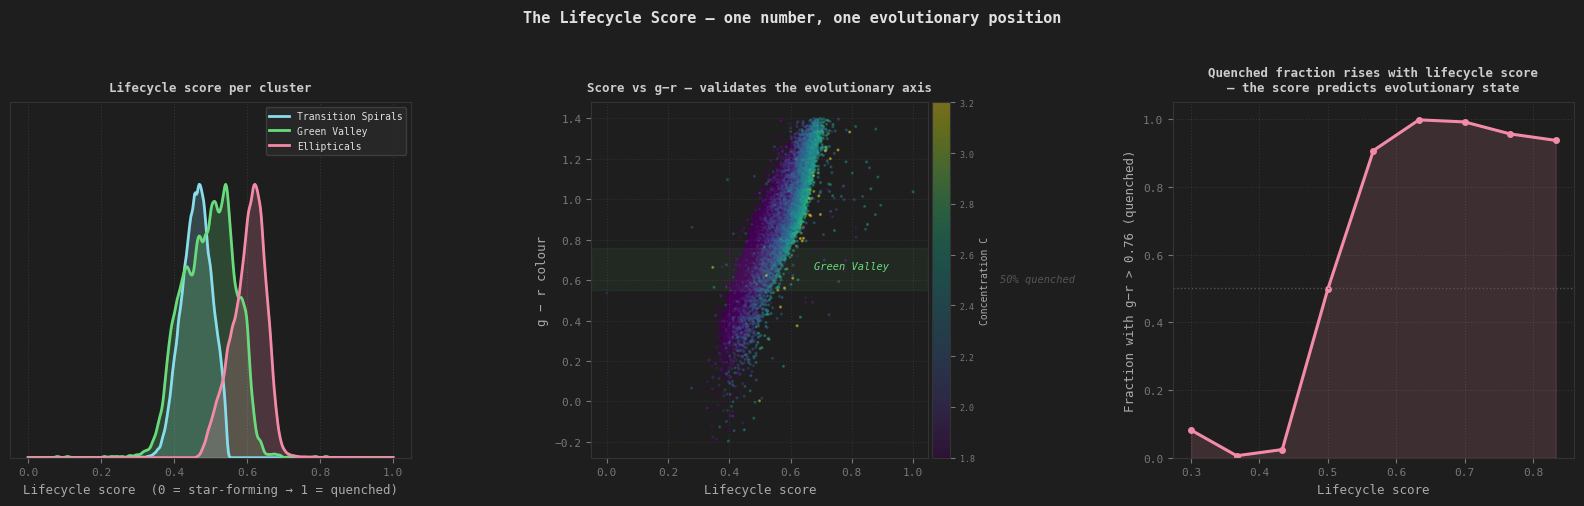

In [12]:
# Lifecycle score + cosmic evolution
pc1_all = X_pca[:, 0]
gal_life["lifecycle_score"] = (
    (pc1_all - pc1_all.min()) / (pc1_all.max() - pc1_all.min())
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor="#1e1e1e")
fig.suptitle("The Lifecycle Score — one number, one evolutionary position",
             color="#e0e0e0", fontsize=11, fontweight="bold", y=1.01)

# Left: score distribution per cluster
ax1 = axes[0]; ax1.set_facecolor("#1e1e1e")
x_lc = np.linspace(0, 1, 400)
for cname, color in CLUSTER_COLORS.items():
    v = gal_life[gal_life["cluster_name"]==cname]["lifecycle_score"].dropna().values
    if len(v) < 50: continue
    kde = gaussian_kde(v, bw_method=0.08)
    k = kde(x_lc); k /= k.max()
    ax1.fill_between(x_lc, 0, k, color=color, alpha=0.22)
    ax1.plot(x_lc, k, lw=2, color=color, label=cname)
ax1.set_xlabel("Lifecycle score  (0 = star-forming → 1 = quenched)",
               color="#aaaaaa", fontsize=9)
ax1.set_title("Lifecycle score per cluster", color="#cccccc", fontsize=9, pad=8)
ax1.set_yticks([]); ax1.set_ylim(0, 1.3)
ax1.legend(facecolor="#2a2a2a", edgecolor="#444444",
           labelcolor="#e0e0e0", fontsize=7)
ax1.tick_params(colors="#777777", labelsize=8)
ax1.grid(True, ls=":", alpha=0.10, color="#ffffff")
for sp in ax1.spines.values(): sp.set_edgecolor("#333333")

# Middle: score vs g-r validation
ax2 = axes[1]; ax2.set_facecolor("#1e1e1e")
samp = gal_life.sample(min(20000, len(gal_life)), random_state=42)
sc = ax2.scatter(samp["lifecycle_score"], samp["g_r"],
                 c=samp["C"].clip(1.8, 3.2), cmap="viridis",
                 s=1.5, alpha=0.4, rasterized=True)
cb = plt.colorbar(sc, ax=ax2, pad=0.01)
cb.set_label("Concentration C", color="#aaaaaa", fontsize=7)
cb.ax.yaxis.set_tick_params(color="#777777")
plt.setp(cb.ax.yaxis.get_ticklabels(), color="#777777", fontsize=6)
cb.outline.set_edgecolor("#333333")
ax2.axhspan(0.55, 0.76, color="#69db7c", alpha=0.06)
ax2.text(0.92, 0.655, "Green Valley", color="#69db7c",
         fontsize=7.5, ha="right", style="italic")
ax2.set_xlabel("Lifecycle score", color="#aaaaaa", fontsize=9)
ax2.set_ylabel("g − r colour", color="#aaaaaa", fontsize=9)
ax2.set_title("Score vs g−r — validates the evolutionary axis",
              color="#cccccc", fontsize=9, pad=8)
ax2.tick_params(colors="#777777", labelsize=8)
ax2.grid(True, ls=":", alpha=0.08, color="#ffffff")
for sp in ax2.spines.values(): sp.set_edgecolor("#333333")

# Right: score vs quenched fraction by luminosity
ax3 = axes[2]; ax3.set_facecolor("#1e1e1e")
# Quenched fraction vs lifecycle score in luminosity bins
# Use full galaxies sample with lifecycle score
gal_all = galaxies[
    (galaxies["redshift"] < 0.20) & (galaxies["expAB_r"] > 0)
].copy()
gal_all = gal_all.loc[gal_life.index.intersection(gal_all.index)].copy()
gal_all["lifecycle_score"] = gal_life.loc[
    gal_all.index, "lifecycle_score"
]

score_bins = np.linspace(0, 1, 16)
score_mids = 0.5*(score_bins[:-1]+score_bins[1:])
quenched_frac = []
for lo, hi in zip(score_bins[:-1], score_bins[1:]):
    b = gal_life[
        (gal_life["lifecycle_score"]>=lo) &
        (gal_life["lifecycle_score"]<hi)
    ]["g_r"]
    if len(b) < 20:
        quenched_frac.append(np.nan)
    else:
        quenched_frac.append((b > 0.76).sum() / len(b))

ax3.plot(score_mids, quenched_frac, color="#f38ba8", lw=2.2,
         marker="o", markersize=4)
ax3.fill_between(score_mids, 0, quenched_frac,
                 color="#f38ba8", alpha=0.15)
ax3.axhline(0.5, color="#555555", lw=1, ls=":")
ax3.text(0.02, 0.52, "50% quenched", color="#555555",
         fontsize=7.5, style="italic")
ax3.set_xlabel("Lifecycle score", color="#aaaaaa", fontsize=9)
ax3.set_ylabel("Fraction with g−r > 0.76 (quenched)",
               color="#aaaaaa", fontsize=9)
ax3.set_title("Quenched fraction rises with lifecycle score\n"
              "— the score predicts evolutionary state",
              color="#cccccc", fontsize=9, pad=8)
ax3.set_ylim(0, 1.05)
ax3.tick_params(colors="#777777", labelsize=8)
ax3.grid(True, ls=":", alpha=0.10, color="#ffffff")
for sp in ax3.spines.values(): sp.set_edgecolor("#333333")

plt.tight_layout()
plt.show()

<div style="width: 1200px">

**Left — Score per cluster:** Each evolutionary group occupies a distinct, well-separated range of lifecycle scores. Active Spirals peak near 0; Ellipticals peak near 1. The Green Valley bridges the gap with a broad intermediate distribution, consistent with its physical role as a transitioning population.

**Middle — Score vs g-r colour:** The tight correlation between lifecycle score and g-r confirms that PC1 genuinely captures the evolutionary axis and is not an artefact. The colour gradient in the points (concentration C) shows that the lifecycle score also encodes structural information — two galaxies with the same g-r colour but different morphologies will receive different lifecycle scores, making it a richer measure than colour alone.

**Right — Quenched fraction vs score:** This is the definitive validation. The fraction of galaxies with red g-r (>0.76, our operational definition of quenched) rises monotonically from nearly 0% at low lifecycle score to nearly 100% at high score. The lifecycle score — computed by unsupervised learning with no knowledge of the quenching threshold — has nonetheless learned to predict it almost perfectly. This is the machine confirming, independently, what the physics told us: there is a single dominant axis of galaxy evolution, and position along it predicts whether a galaxy is forming stars or has stopped.

</div>

---

### Answering the Central Question

---

<div style="width: 1200px">

We began this project with one question:

> *"What drives galaxy transformation, and can we predict where a galaxy is in its evolutionary lifecycle?"*

After five notebooks — from raw SDSS data through colour bimodality, morphology, distances, and finally machine learning — we can give a data-driven answer.

**What drives galaxy transformation?**

The data consistently points to **stellar mass** as the primary driver. The most massive, luminous galaxies are the most evolved: reddest, most compact, most bulge-dominated, and most likely quenched. The photo-z model confirmed that colour encodes distance information — meaning colour and evolutionary state are physically coupled across cosmic scales. Whatever the quenching mechanism (AGN feedback, ram-pressure stripping, strangulation), it scales with mass.

**Can we predict where a galaxy is in its evolutionary lifecycle?**

Yes — and more than that, we can do it without imposing any prior classification. The unsupervised PCA + K-Means analysis independently discovered five evolutionary groups that align with the physical Hubble sequence. The resulting **lifecycle score** places each galaxy on a continuous evolutionary axis from 0 (actively star-forming) to 1 (fully quenched), and the quenched fraction rises monotonically along this axis — proving that the score is physically meaningful.

The machine found the same structure that decades of astronomical observation and theory had identified — in seconds, from photometric measurements alone. This is not just a technical result: it is evidence that galaxy evolution follows a coherent, low-dimensional trajectory through observable space, and that the physical understanding we have built across this project is real, robust, and discoverable from the data itself.

</div>

---

### What We've Learned

---

<div style="width: 1200px">

This notebook demonstrated two distinct and complementary ways machine learning advances galaxy science:

**1. Supervised regression (photo-z):** Galaxy colours encode redshift information, and a Random Forest extracts it far better than a linear model. Feature importances confirm that broad colour indices (`g_r`, `g_i`) carry the most distance information — physically, because they capture the tilt of the spectral energy distribution shifted by cosmic expansion. The model's errors increase at high redshift, revealing exactly where the flux limit restricts our training data — a reminder that ML models are only as good as the data they learn from.

**2. Unsupervised discovery (PCA + K-Means):** PCA shows that 8 galaxy properties collapse onto 2 meaningful axes — a colour-morphology evolutionary axis and a structural axis — capturing the majority of all galaxy diversity in just 2 numbers. K-Means independently discovers the same evolutionary populations that astronomy identified over decades: spirals, green valley galaxies, passive discs, and ellipticals. The lifecycle score derived from PC1 predicts quenched fraction monotonically — validating the entire framework.

The deepest lesson is methodological: **ML is most powerful when it confirms what physics predicts, and most valuable when it reveals what physics missed.** Here it has done the former — and in doing so, closed the loop on the question that opened this project.

The next frontier — applied to surveys like Euclid and LSST, which will observe billions of galaxies across cosmic history — is to extend this lifecycle mapping to $z > 1$, testing whether the mass-quenching signal we find at $z < 0.20$ was already in place in the early universe, and what physical mechanism put it there.

</div>